# Operator Dynamics in Random Bricklayer Circuits with Pauli chain Propagation and Matrix Product Operator (MPO) propagation

I've written some Julia module,
- `matrix_product_operator_functions.jl`, based on the MPO evolution method and the `ITensors.jl` (and `ITensorMPS.jl`) package for managing tensors,
- `pauli_propagation_functions.jl`, based on the paper “*Pauli Propagation: A Computational Framework for Simulating Quantum Systems*”[1] and the associated package `PauliPropagation.jl`,
- `exact_functions.jl`, which simply calculates the “theoretical,” exact results of a propagation,
- `circuit.jl`, which allows you to initialize different types of circuits, including the MFIM, for the different methods we will need in this notebook.

These module allows me to handle propagation of an observable (in the Heisenberg picture) through a quantum circuit.

The goal of this notebook is to study the time evolution of a local quantum observable and examine how the complexity of these methods scales with the number of qubits.

In [ ]:
# using Pkg; Pkg.add("LaTeXStrings"); Pkg.add("PauliPropagation"); Pkg.add("ITensors"); Pkg.add("ITensorMPS")

In [ ]:
using LaTeXStrings
using Plots
using LinearAlgebra
import Statistics: mean

# --- Pauli Propagation ---
using PauliPropagation

#include("../src/pauli_propagation_functions.jl")
include("pauli_propagation_functions.jl")
import .pauli_propagation_functions as pp

# --- MPO ---
using ITensors, ITensorMPS

#include("../src/matrix_product_operator_functions.jl")
include("matrix_product_operator_functions.jl")
import .mpo_functions as mpo

# --- Exact method ---

#include("../src/exact_functions.jl")
include("exact_functions.jl")
import .exact_functions as ext

# --- other ---
#include("../src/utils.jl")
include("utils.jl")
import .utils as us

#include("../src/circuit.jl")
include("circuit.jl")
import .circuit as ct

---

# 1. Random Gate Circuit

We will use a random brick layer circuits, All $U$ gates (that apply only between nearest neighbors), must follow a **uniform distribution**, so we will use the **Haar distribution** [2] for generate this $4 \times 4$ matrix.

## 1.1 Mezzadri algo for Haar distribution

1.  **Generation of $Z$**: We create an $n \times n$ matrix where each element is a complex number $a + ib$, with $a, b \sim \mathcal{N}(0, 1)$.
2.  **QR decomposition**: We compute $Q$ and $R$ such that $Z = QR$.
3.  **Phase correction**: We define a diagonal matrix $\Lambda$ such that:
$$\Lambda_{ii} = \frac{R_{ii}}{|R_{ii}|}$$
  The diagonal elements of $R' = \Lambda^{-1}R$ are always real and strictly positive, therefore the matrix $Q' = Q\Lambda$ is **distributed with Haar measure**.

We then compute the final unitary matrix: $U = Q \times \Lambda$.



In [ ]:
U = ct.haar_unitary(4)

4×4 Matrix{ComplexF64}:
 -0.550213+0.206449im  -0.435283-0.382522im    …   0.485106-0.0367188im
  0.124355-0.623477im  -0.187373-0.255468im       -0.154967-0.612734im
    0.1341-0.261788im  -0.161038-0.00518566im      0.441685+0.20935im
 0.0418225-0.402732im  -0.337966+0.650885im        0.244267+0.255512im

And we can verify if $U$ is unitary.

In [ ]:
U * U' ≈ U' * U ≈ I(4)

true

---

## 1.2 Matrices to gates

Now we want to use these random unitary matrices as gates to build a quantum circuit of the type :

<img src="https://github.com/TheoHUETQC/Quantum-ManyBody-Sim-Methods/blob/main/figures/brickwork_pattern_circuit.png?raw=1" width="600" alt="Block circuit">

All U are different random 4x4 matrices.

To use the random matrices we have and will construct as gates, we will need to apply transformations to them. In fact, each method requires the gate to be of a certain type.

- For the PauliPropagation method, the package allows us to do this using the function `TransferMapGate()`,
- The MPO method need to convert the matrix in tensor which will apply to sites[i], sites[j], we use `itensor()`,
- And for the exact method, we need to transform $U$, which is a $4\times 4$ matrix, into a matrix of size $2^N \times 2^N$: $\mathbb{I} \otimes \dots \otimes U \otimes \dots \otimes \mathbb{I}$, we use the function `local_to_global_matrices()` in the circuit module.

In [ ]:
# U_pp, U_mpo, U_exact = ct.matrix_to_gate(U, (1,2), 4)

---

# 2. Method's Complexity

Now that we have built the random circuit, we need to determine, as we did in the first notebook, which method is most effective for propagating an observable, in this case a local one, through this type of random evolution.

## 2.1 initialisation

In [ ]:
# define the circuit
nlayers = 100

# for Z_i
i = 2

truncation_tolerance = 1e-2
error_tolerance = 1e-1 # for the matrix and overlap comparaison with exact result

function initialisation(nqubits::Int64, nlayers::Int64, i::Int64)
  circuit_pp, circuit_mpo, circuit_exact, sites = ct.random_circuit(nqubits, nlayers)

  # Exact
  ψ0_exact = append!([1.],[0. for _ in 2:(2^nqubits)]) # |0> state
  Z_i_exact = ext.get_Zi(nqubits, i)

  # Pauli
  ψ0_pp = ψ0_exact # |0> state
  Z_i_pp = PauliString(nqubits, :Z, i) # I...IZI...I

  # MPO
  ψ0_mps = MPS(sites, "0") # |↑↑..↑>
  ops = ["Id" for n in 1:nqubits]
  ops[i] = "Z"
  Z_i_mpo = MPO(sites, ops)

  return circuit_pp, circuit_mpo, circuit_exact, sites, ψ0_pp, ψ0_mps, ψ0_exact, Z_i_pp, Z_i_mpo, Z_i_exact
end

4

---

## 2.2 Propagation

--------------- 3=qubits ---------------
--------- Exact method propagation ---------
layer : 10 /100 complete
layer : 20 /100 complete
layer : 30 /100 complete
layer : 40 /100 complete
layer : 50 /100 complete
layer : 60 /100 complete
layer : 70 /100 complete
layer : 80 /100 complete
layer : 90 /100 complete
layer : 100 /100 complete
Time taken by ext.propagate_layerbylayer: 0.0007607936859130859 seconds
--------- method Pauli propagation ---------
Optimal truncations find : (Max weight=3, Min abs coeff=1e-4)
layer : 10/100 complete
layer : 20/100 complete
layer : 30/100 complete
layer : 40/100 complete
layer : 50/100 complete
layer : 60/100 complete
layer : 70/100 complete
layer : 80/100 complete
layer : 90/100 complete
layer : 100/100 complete
Time taken by pp.propagate_layerbylayer: 0.030807018280029297 seconds
--------- MPO method propagation ---------
Optimal truncations find : (Maxdim=5, Cutoff=1e-4)
layer : 10 /100 complete
layer : 20 /100 complete
layer : 30 /100 complete
laye

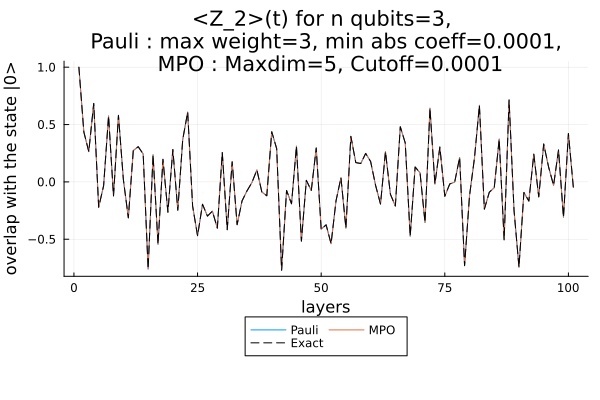

--- Matrix Errors ---
Z2(t_final) Pauli vs Exact close (tol=0.1)? true
Z2(t_final) MPO vs Exact close (tol=0.1)? false
Mean matrix error (Pauli): 4.103102837047663e-5
Mean matrix error (MPO): 0.3354145581168652

--- Overlap Curve Errors ---
Overlap Pauli vs Exact close (tol=0.1)? true
Overlap MPO vs Exact close (tol=0.1)? true
Max overlap error (Pauli): 9.446564224882548e-5
Max overlap error (MPO): 1.8290924330699454e-14
--------------- 5=qubits ---------------
--------- Exact method propagation ---------
layer : 10 /100 complete
layer : 20 /100 complete
layer : 30 /100 complete
layer : 40 /100 complete
layer : 50 /100 complete
layer : 60 /100 complete
layer : 70 /100 complete
layer : 80 /100 complete
layer : 90 /100 complete
layer : 100 /100 complete
Time taken by ext.propagate_layerbylayer: 0.01772904396057129 seconds
--------- method Pauli propagation ---------
Optimal truncations find : (Max weight=5, Min abs coeff=1e-5)
layer : 10/100 complete
layer : 20/100 complete
layer : 30/10

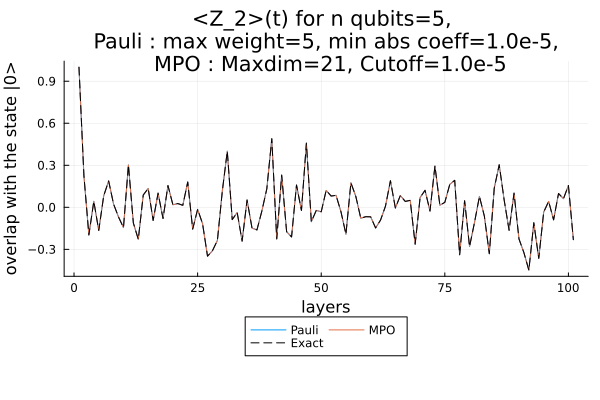

--- Matrix Errors ---
Z2(t_final) Pauli vs Exact close (tol=0.1)? true
Z2(t_final) MPO vs Exact close (tol=0.1)? false
Mean matrix error (Pauli): 8.08040832270831e-6
Mean matrix error (MPO): 0.19708995650622194

--- Overlap Curve Errors ---
Overlap Pauli vs Exact close (tol=0.1)? true
Overlap MPO vs Exact close (tol=0.1)? true
Max overlap error (Pauli): 2.0779827458988764e-5
Max overlap error (MPO): 3.3639757646142243e-14
--------------- 7=qubits ---------------
--------- Exact method propagation ---------
layer : 10 /100 complete
layer : 20 /100 complete
layer : 30 /100 complete
layer : 40 /100 complete
layer : 50 /100 complete
layer : 60 /100 complete
layer : 70 /100 complete
layer : 80 /100 complete
layer : 90 /100 complete
layer : 100 /100 complete
Time taken by ext.propagate_layerbylayer: 2.2666800022125244 seconds
--------- method Pauli propagation ---------
Optimal truncations find : (Max weight=7, Min abs coeff=1e-6)
layer : 10/100 complete
layer : 20/100 complete
layer : 30/10

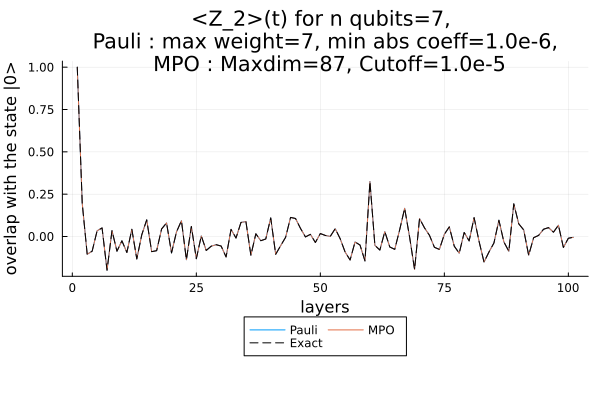

--- Matrix Errors ---
Z2(t_final) Pauli vs Exact close (tol=0.1)? true
Z2(t_final) MPO vs Exact close (tol=0.1)? true
Mean matrix error (Pauli): 1.4635965458213288e-6
Mean matrix error (MPO): 0.09823185918502583

--- Overlap Curve Errors ---
Overlap Pauli vs Exact close (tol=0.1)? true
Overlap MPO vs Exact close (tol=0.1)? true
Max overlap error (Pauli): 4.802756407865094e-6
Max overlap error (MPO): 0.0004561664978081359
--------------- 9=qubits ---------------
--------- Exact method propagation ---------
layer : 10 /100 complete
layer : 20 /100 complete
layer : 30 /100 complete
layer : 40 /100 complete
layer : 50 /100 complete
layer : 60 /100 complete
layer : 70 /100 complete
layer : 80 /100 complete
layer : 90 /100 complete
layer : 100 /100 complete
Time taken by ext.propagate_layerbylayer: 62.289072036743164 seconds
--------- method Pauli propagation ---------
Optimal truncations find : (Max weight=9, Min abs coeff=1e-6)
layer : 10/100 complete
layer : 20/100 complete
layer : 30/100

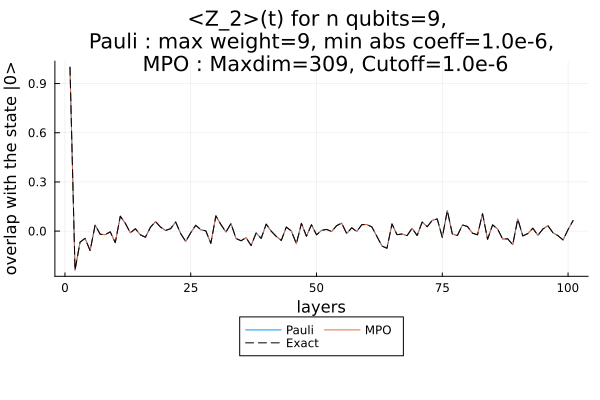

--- Matrix Errors ---
Z2(t_final) Pauli vs Exact close (tol=0.1)? true
Z2(t_final) MPO vs Exact close (tol=0.1)? true
Mean matrix error (Pauli): 6.3964559633762615e-6
Mean matrix error (MPO): 0.04976077793083547

--- Overlap Curve Errors ---
Overlap Pauli vs Exact close (tol=0.1)? true
Overlap MPO vs Exact close (tol=0.1)? true
Max overlap error (Pauli): 1.309474692954421e-5
Max overlap error (MPO): 0.00012196946421760314


In [ ]:
times_exact, times_pp, times_mpo = Float64[], Float64[], Float64[]
truncations_mpo, truncations_pp = Tuple{Int64, Float64}[], Tuple{Int64, Float64}[]

Ns = 3:2:9
for nqubits in Ns
  println("--------------- $nqubits=qubits ---------------")
  circuit_pp, circuit_mpo, circuit_exact, sites, ψ0_pp, ψ0_mps, ψ0_exact, Z_i_pauliString, Z_i_mpo, Z_i_exact = initialisation(nqubits, nlayers, i)

  # Exact method
  println("--------- Exact method propagation ---------")
  Zi_t_exact, result_exact = ext.propagate_layerbylayer(circuit_exact, Z_i_exact; ψ0=ψ0_exact)
  overlap_exact = result_exact["overlap"]

  # Pauli
  println("--------- method Pauli propagation ---------")
  ## test truncation
  (max_weight, min_abs_coeff) = pp.find_truncations(truncation_tolerance, circuit_pp, Z_i_pauliString, nlayers)

  ## optimal truncation application
  Zi_t_pauli_propagation, result_pp = pp.propagate_layerbylayer(circuit_pp, Z_i_pauliString, nlayers; max_weight, min_abs_coeff, ψ0=ψ0_pp)
  overlap_pp = result_pp["overlap"]

  ## pauli sum -> matrix
  Zi_t_pauli_propagation_matrix = pp.compute_matrix(Zi_t_pauli_propagation)

  # MPO
  println("--------- MPO method propagation ---------")
  ## test truncation
  (maxdim, cutoff) = mpo.find_truncations(truncation_tolerance, circuit_mpo, Z_i_mpo)

  ## optimal truncation application
  Zi_t_mpo, result_mpo = mpo.propagate_layerbylayer(circuit_mpo, Z_i_mpo; cutoff, maxdim, ψ0=ψ0_mps)
  overlap_mpo = result_mpo["overlap"]

  ## Itensor -> matrix
  Zi_t_mpo_matrix = mpo.compute_matrix(Zi_t_mpo, sites)

  # plot and print
  println("--------- Plot & Result ---------")
  us.overlap_with_Zi_plot(nqubits, overlap_pp, overlap_mpo, overlap_exact, i, max_weight, min_abs_coeff, maxdim, cutoff)
  us.print_methods_error(Zi_t_exact, Zi_t_pauli_propagation_matrix, Zi_t_mpo_matrix, overlap_exact, overlap_pp, overlap_mpo, error_tolerance; operatorName="Z$i")

  # push the time of propagation to see complexity
  push!(truncations_pp, (max_weight, min_abs_coeff))
  push!(truncations_mpo, (maxdim, cutoff))
  push!(times_exact, result_exact["time"])
  push!(times_pp, result_pp["time"])
  push!(times_mpo, result_mpo["time"])
end


## 2.3 Complexity plots

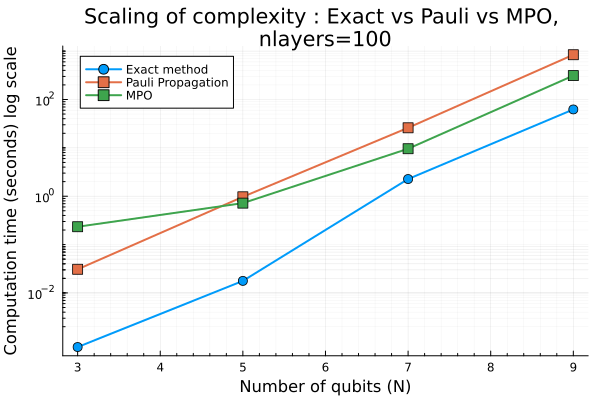

In [ ]:
us.complexity_plot(Ns, nlayers, times_exact, times_pp, times_mpo; logscale=true)

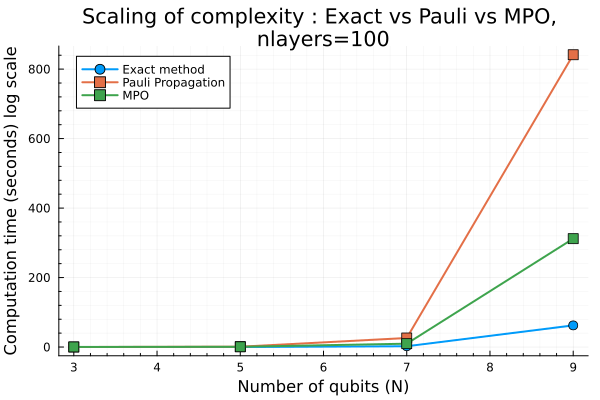

In [ ]:
us.complexity_plot(Ns, nlayers, times_exact, times_pp, times_mpo)

It is clear that the exact method outperforms our methods (MPO and Pauli propagation). Unlike in the previous notebook, given the increase in computation time, the exact method will continue to outperform our methods as the number of qubits increases.

## 2.4 Truncations plots

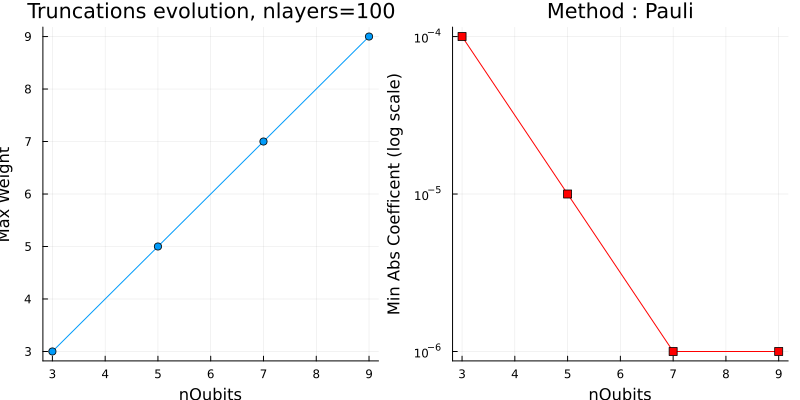

In [ ]:
us.truncation_plot(Ns, truncations_pp; method="Pauli", title="Truncations evolution, nlayers=$nlayers", parameterName="nQubits")

For a maximum weight below the number of Qubits, our method troncate $c_\alpha$ wich are important for the physical state.

This seems consistent with the type of circuit through which we propagate our observable.
Indeed, a circuit composed of random gates creates a lot of correlation between the qubits. Consequently, a max weight that is too small avoids strong correlations and thus takes us drastically away from the exact physical state, which is highly correlated.

As they said in their research paper about this method:
> complex quantum dynamics may generate a considerable number of new Pauli strings – exponential in the number of non-Clifford gates – each with a small coefficien



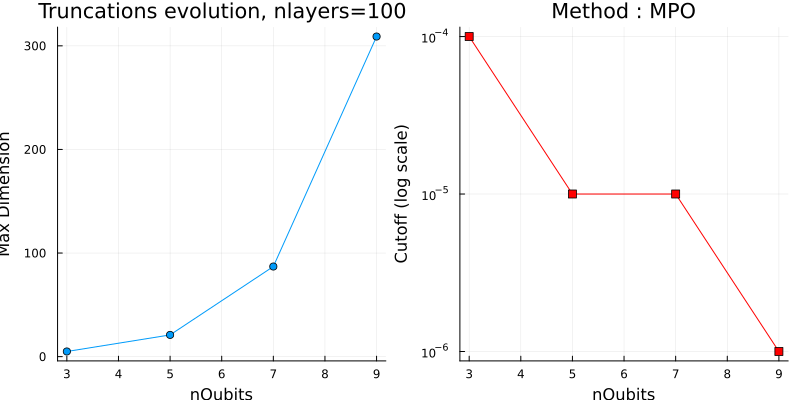

In [ ]:
us.truncation_plot(Ns, truncations_mpo; method="MPO", title="Truncations evolution, nlayers=$nlayers", parameterName="nQubits")

Similarly, here we see that the truncation is small; the max bond dimension follows an exponential law, which is also due to the fact that the circuit creates a lot of correlation between the qubits.

---

# 3. Thermalisation

If we look now at the overlap graphs in the Propagation part (2.2), we can see that, starting at a certain point in the circuit, after a certain amount of time, our system stabilizes, at least in terms of overlap. This time is called the **thermalization time**.

Let's look at the average overlap of our system after thermalization, which we'll set at 25% of our circuit.

In [ ]:
therm_layer = nlayers ÷ 4 # we let 25% of the circuit for the system to be thermalized

25

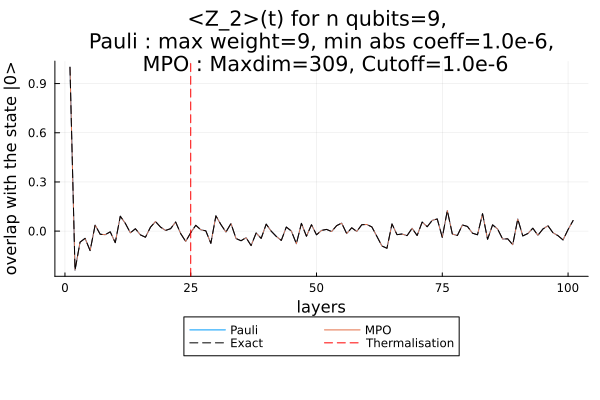

In [ ]:
us.overlap_with_Zi_plot(Ns[end], overlap_pp, overlap_mpo, overlap_exact, i, max_weight, min_abs_coeff, maxdim, cutoff; thermalisation=therm_layer)

In [ ]:
overlap_result_average_pp = mean(overlap_pp[therm_layer:end])
println(overlap_result_average_pp)

-0.00010515693395868024


In [ ]:
overlap_result_average_mpo = mean(overlap_mpo[therm_layer:end])
println(overlap_result_average_mpo)

-0.00010080465646388701


As can be seen from the graph and the average, our overlap is around 0.

But we know that:

$$\langle \psi_0|\hat O(t) |\psi_0\rangle = 0 \implies Tr(\rho_0 \hat O(t)) = Tr(\rho(t) \hat O(t=0)) = 0$$

here $\hat O(t=0) = Z_i$ so:

$$\implies Tr(\rho(t) Z_i) = 0 \implies \rho(t) = \mathbb I$$

Because $Tr(Z_i) = 0 \quad \forall i \in \mathbb N$

Which means that a random circuit will bring our density matrix close to the identity matrix, and our system will stabilize around a **maximally mixed state**.

In the next notebook, we'll take a look at how our system thermalise with different noise levels.

---

# References

### Paper
- [1] [Pauli Propagation](https://arxiv.org/abs/2505.21606)
- [2] [Haar Random Matrix](https://arxiv.org/abs/math-ph/0609050)

### Julia Package
- [Julia documentation](https://docs.julialang.org/en/v1/)
- [PauliPropagation.jl](https://github.com/MSRudolph/PauliPropagation.jl)
- [ITensor documentation](https://docs.itensor.org/ITensors/stable/index.html)
- [Plots documentation](https://docs.juliaplots.org/stable/)
- [LinearAlgebra documentation](https://docs.julialang.org/en/v1/stdlib/LinearAlgebra/)
- [LaTeXStrings documentation](https://juliapackages.com/p/latexstrings)

### Other
- Latex Tiks documentation https://www.overleaf.com/learn/latex/LaTeX_Graphics_using_TikZ%3A_A_Tutorial_for_Beginners_(Part_3)%E2%80%94Creating_Flowcharts